<a href="https://colab.research.google.com/github/samyakbaid/ML_coding_questions/blob/main/assingment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Q2 (Part A): PCA Plots for Question 2(c)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

In [6]:
data = np.array([[1,1],[2,2],[3,2],[4,3]], dtype=float)
mean = data.mean(axis=0)
X_c = data - mean
Sigma = (X_c.T @ X_c) / len(data)
print(f"Mean         : {mean}")
print(f"Cov matrix   :\n{Sigma}")

Mean         : [2.5 2. ]
Cov matrix   :
[[1.25 0.75]
 [0.75 0.5 ]]


In [7]:
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

v1 = eigenvectors[:, 0]
projections = X_c @ v1

print(f"Eigenvalues  : {eigenvalues}")
print(f"PC1 direction: {v1}")
print(f"Projections  : {projections}")

Eigenvalues  : [1.71352549 0.03647451]
PC1 direction: [-0.85065081 -0.52573111]
Projections  : [ 1.80170732  0.4253254  -0.4253254  -1.80170732]


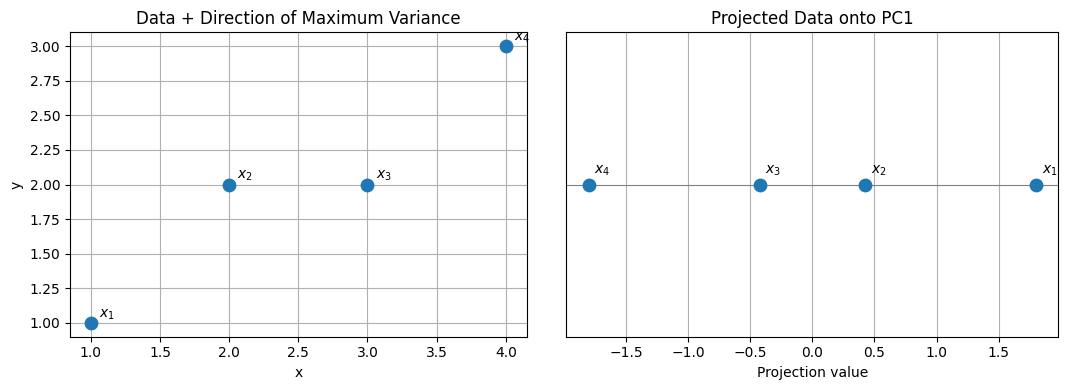

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.scatter(data[:, 0], data[:, 1], s=80, zorder=3)
for i, pt in enumerate(data):
    ax.annotate(f'$x_{i+1}$', pt, textcoords='offset points', xytext=(6, 4))
scale = 2.2
ax.annotate('', xy=mean + scale * v1, xytext=mean - scale * v1,
            arrowprops=dict(arrowstyle='->', color='tomato', lw=2))
ax.set_title('Data + Direction of Maximum Variance')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_aspect('equal'); ax.grid(True)

ax = axes[1]
ax.scatter(projections, np.zeros_like(projections), s=80, zorder=3)
for i, p in enumerate(projections):
    ax.annotate(f'$x_{i+1}$', (p, 0), textcoords='offset points', xytext=(4, 8))
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('Projected Data onto PC1')
ax.set_xlabel('Projection value')
ax.set_yticks([]); ax.grid(True)

plt.tight_layout()
plt.savefig('pca_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## Q1 (Part B) :  Soft-Margin SVM on Breast Cancer Dataset

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [10]:
raw = load_breast_cancer()
X_all = raw.data
y_all = (raw.target * 2 - 1).astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Label distribution (train)  +1: {(y_train==1).sum()}  -1: {(y_train==-1).sum()}")

Train: (455, 30)  |  Test: (114, 30)
Label distribution (train)  +1: 285  -1: 170


In [11]:
def build_svm_problem(X, y, C):
    n = len(y)
    K = X @ X.T
    YK = (y[:, None] * y[None, :]) * K

    def neg_dual(alpha):
        return 0.5 * alpha @ YK @ alpha - alpha.sum()

    def neg_dual_grad(alpha):
        return YK @ alpha - np.ones(n)

    constraints = [{'type': 'eq', 'fun': lambda a: a @ y, 'jac': lambda a: y}]
    bounds = [(0, C)] * n
    alpha0 = np.zeros(n)
    return neg_dual, neg_dual_grad, constraints, bounds, alpha0

def solve_svm(X, y, C=1.0):
    f, g, cons, bounds, a0 = build_svm_problem(X, y, C)
    result = minimize(f, a0, jac=g, method='SLSQP',
                      bounds=bounds, constraints=cons,
                      options={'maxiter': 2000, 'ftol': 1e-9})
    return result.x

print("SVM solver defined.")

SVM solver defined.


In [12]:
C = 1.0
alpha = solve_svm(X_train, y_train, C=C)

sv_mask   = alpha > 1e-5
sv_margin = (alpha > 1e-5) & (alpha < C - 1e-5)

w = (alpha * y_train) @ X_train

sv_margin_idx = np.where(sv_margin)[0]
b_vals = y_train[sv_margin_idx] - X_train[sv_margin_idx] @ w
b = b_vals.mean()

print(f"Total support vectors  : {sv_mask.sum()}")
print(f"Margin support vectors : {sv_margin.sum()}")
print(f"||w||                  : {np.linalg.norm(w):.4f}")
print(f"b                      : {b:.4f}")

Total support vectors  : 32
Margin support vectors : 15
||w||                  : 3.0648
b                      : 0.0489


In [13]:
def predict(X, w, b):
    return np.sign(X @ w + b)

train_acc = (predict(X_train, w, b) == y_train).mean()
test_acc  = (predict(X_test,  w, b) == y_test ).mean()

print(f"Train accuracy : {train_acc*100:.2f}%")
print(f"Test  accuracy : {test_acc*100:.2f}%")

Train accuracy : 99.12%
Test  accuracy : 97.37%


In [14]:
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
train_accs, test_accs, sv_counts = [], [], []

for c in C_values:
    a = solve_svm(X_train, y_train, C=c)
    sv = a > 1e-5
    sv_m = (a > 1e-5) & (a < c - 1e-5)
    ww = (a * y_train) @ X_train
    idx = np.where(sv_m)[0]
    bb = (y_train[idx] - X_train[idx] @ ww).mean() if len(idx) > 0 else 0.0
    ta = (predict(X_train, ww, bb) == y_train).mean()
    tea = (predict(X_test,  ww, bb) == y_test ).mean()
    train_accs.append(ta); test_accs.append(tea); sv_counts.append(sv.sum())
    print(f"C={c:6.2f}  SVs={sv.sum():4d}  Train={ta*100:.1f}%  Test={tea*100:.1f}%")

C=  0.01  SVs=  99  Train=97.8%  Test=96.5%
C=  0.10  SVs=  51  Train=98.5%  Test=98.2%
C=  1.00  SVs=  32  Train=99.1%  Test=97.4%
C= 10.00  SVs=  26  Train=99.1%  Test=98.2%
C=100.00  SVs=  26  Train=99.6%  Test=97.4%


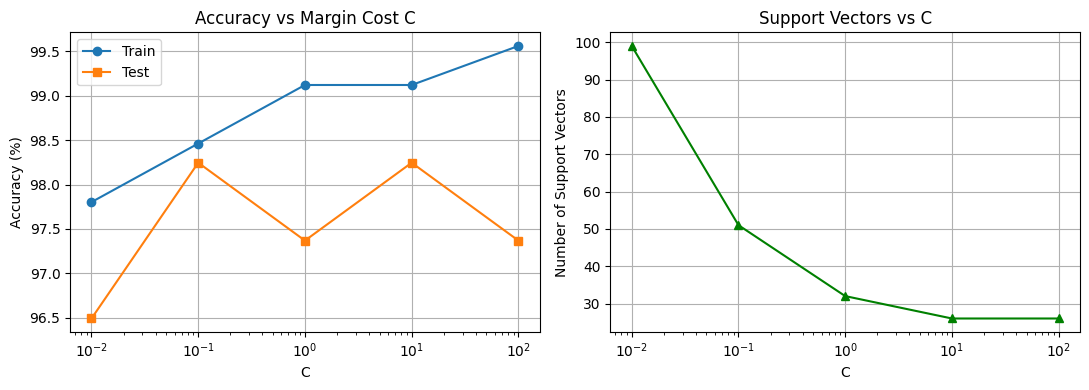

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogx(C_values, [t*100 for t in train_accs], marker='o', label='Train')
axes[0].semilogx(C_values, [t*100 for t in test_accs],  marker='s', label='Test')
axes[0].set_xlabel('C'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Accuracy vs Margin Cost C')
axes[0].legend(); axes[0].grid(True)

axes[1].semilogx(C_values, sv_counts, marker='^', color='green')
axes[1].set_xlabel('C'); axes[1].set_ylabel('Number of Support Vectors')
axes[1].set_title('Support Vectors vs C')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [16]:
print(".  Q1 SVM Diagnostic    ")
print(f"Algorithm     : Soft-Margin SVM (dual formulation, SLSQP via scipy)")
print(f"Dataset       : Breast Cancer Wisconsin ({X_all.shape[0]} samples, {X_all.shape[1]} features)")
print(f"Margin cost C : {C}")
print(f"Support vectors (C=1): {sv_mask.sum()} total, {sv_margin.sum()} on margin")
print(f"Final result  : Train {train_acc*100:.2f}%  |  Test {test_acc*100:.2f}%")

.  Q1 SVM Diagnostic    
Algorithm     : Soft-Margin SVM (dual formulation, SLSQP via scipy)
Dataset       : Breast Cancer Wisconsin (569 samples, 30 features)
Margin cost C : 1.0
Support vectors (C=1): 32 total, 15 on margin
Final result  : Train 99.12%  |  Test 97.37%


## Q2 (Part B) : K-Means from Scratch on Iris

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [18]:
iris = load_iris()
X_iris = iris.data
print(f"Iris dataset : {X_iris.shape}")
print(f"Features     : {iris.feature_names}")

Iris dataset : (150, 4)
Features     : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [19]:
class KMeans:
    def __init__(self, k, max_iter=300, tol=1e-6, seed=42):
        self.k        = k
        self.max_iter = max_iter
        self.tol      = tol
        self.seed     = seed

    def fit(self, X):
        rng = np.random.default_rng(self.seed)
        idx = rng.choice(len(X), self.k, replace=False)
        self.centroids_ = X[idx].copy()

        for _ in range(self.max_iter):
            labels = self._assign(X)
            new_centroids = np.array([
                X[labels == j].mean(axis=0) if (labels == j).any() else self.centroids_[j]
                for j in range(self.k)
            ])
            if np.linalg.norm(new_centroids - self.centroids_) < self.tol:
                break
            self.centroids_ = new_centroids

        self.labels_ = self._assign(X)
        self.inertia_ = self._inertia(X)
        return self

    def _assign(self, X):
        dists = np.linalg.norm(X[:, None, :] - self.centroids_[None, :, :], axis=2)
        return np.argmin(dists, axis=1)

    def _inertia(self, X):
        return sum(
            np.sum((X[self.labels_ == j] - self.centroids_[j]) ** 2)
            for j in range(self.k)
        )

print("KMeans class defined.")

KMeans class defined.


In [20]:
K_values  = [2, 3, 4, 5]
models    = {}
inertias  = {}

for k in K_values:
    km = KMeans(k=k).fit(X_iris)
    models[k]   = km
    inertias[k] = km.inertia_
    print(f"k={k}  inertia={km.inertia_:.2f}")

k=2  inertia=152.35
k=3  inertia=78.86
k=4  inertia=57.23
k=5  inertia=51.17


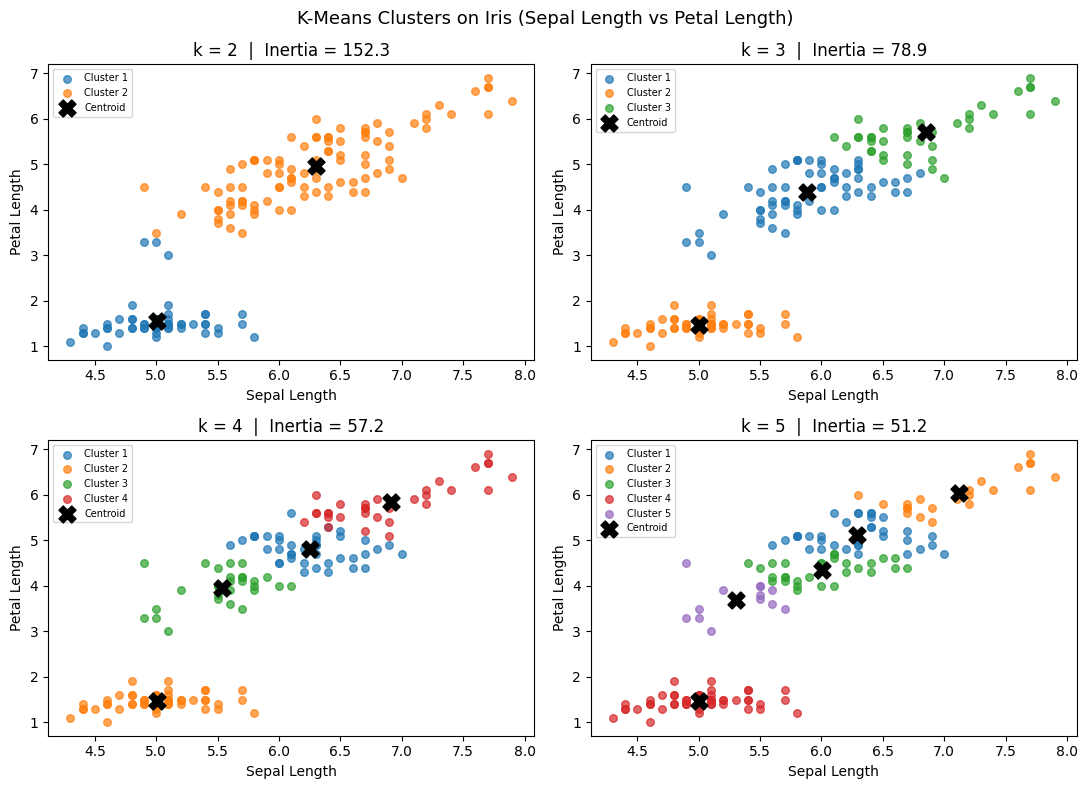

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

for i, k in enumerate(K_values):
    ax  = axes[i]
    km  = models[k]
    lbl = km.labels_
    for j in range(k):
        pts = X_iris[lbl == j]
        ax.scatter(pts[:, 0], pts[:, 2], s=30, alpha=0.7, label=f'Cluster {j+1}')
    ax.scatter(km.centroids_[:, 0], km.centroids_[:, 2],
               marker='X', s=150, c='black', zorder=5, label='Centroid')
    ax.set_title(f'k = {k}  |  Inertia = {inertias[k]:.1f}')
    ax.set_xlabel('Sepal Length'); ax.set_ylabel('Petal Length')
    ax.legend(fontsize=7)

plt.suptitle('K-Means Clusters on Iris (Sepal Length vs Petal Length)', fontsize=13)
plt.tight_layout()
plt.show()

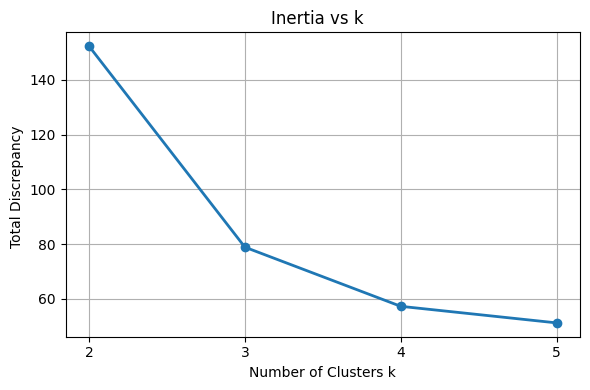

In [22]:
plt.figure(figsize=(6, 4))
plt.plot(K_values, [inertias[k] for k in K_values], marker='o', linewidth=2)
plt.xlabel('Number of Clusters k')
plt.ylabel('Total Discrepancy ')
plt.title('Inertia vs k  ')
plt.xticks(K_values)
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
print(". Q2 K-Means Diagnostic ")
print("Algorithm    : K-Means (random init, Euclidean distance, from scratch)")
print("Dataset      : Iris (150 samples, 4 features)")
print(f"K values     : {K_values}")
for k in K_values:
    print(f"  k={k}  inertia={inertias[k]:.2f}")
print("Elbow visible at k=3 and consistent with 3 true species in Iris.")

. Q2 K-Means Diagnostic 
Algorithm    : K-Means (random init, Euclidean distance, from scratch)
Dataset      : Iris (150 samples, 4 features)
K values     : [2, 3, 4, 5]
  k=2  inertia=152.35
  k=3  inertia=78.86
  k=4  inertia=57.23
  k=5  inertia=51.17
Elbow visible at k=3 and consistent with 3 true species in Iris.


## Q3 (Part B):  Autoencoder on Fashion-MNIST

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")

Device : cpu


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")

Device : cpu


In [26]:
class Autoencoder(nn.Module):
    def __init__(self, hidden_sizes, latent_dim):
        super().__init__()
        enc_layers, dec_layers = [], []
        in_dim = 784
        for h in hidden_sizes:
            enc_layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        enc_layers.append(nn.Linear(in_dim, latent_dim))
        self.encoder = nn.Sequential(*enc_layers)

        in_dim = latent_dim
        for h in reversed(hidden_sizes):
            dec_layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        dec_layers += [nn.Linear(in_dim, 784), nn.Sigmoid()]
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x):
        z = self.encoder(x.view(-1, 784))
        return self.decoder(z).view(-1, 1, 28, 28)

print("Autoencoder class defined.")

Autoencoder class defined.


In [27]:
def train_autoencoder(model, train_loader, val_loader, epochs=15, lr=1e-3):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, imgs)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            running += loss.item() * len(imgs)
        train_losses.append(running / len(train_loader.dataset))

        model.eval()
        v_running = 0.0
        with torch.no_grad():
            for imgs, _ in val_loader:
                imgs = imgs.to(DEVICE)
                out  = model(imgs)
                v_running += criterion(out, imgs).item() * len(imgs)
        val_losses.append(v_running / len(val_loader.dataset))

    return train_losses, val_losses

print("Training function defined.")

Training function defined.


In [29]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)


train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_data, val_data = random_split(train_dataset, [train_size, val_size])

batch_size = 256
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_dataset)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 16.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 269kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.04MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 31.2MB/s]

Train samples: 48000
Validation samples: 12000
Test samples: 10000


In [30]:
configs = [
    {'name': 'Small   (latent=16)',  'hidden': [128],       'latent': 16},
    {'name': 'Medium  (latent=32)',  'hidden': [256, 128],  'latent': 32},
    {'name': 'Large   (latent=64)',  'hidden': [512, 256],  'latent': 64},
    {'name': 'XLarge  (latent=128)', 'hidden': [512, 256, 128], 'latent': 128},
]

results = {}
EPOCHS = 15

for cfg in configs:
    model = Autoencoder(cfg['hidden'], cfg['latent'])
    params = sum(p.numel() for p in model.parameters())
    t0 = time.time()
    tr_loss, val_loss = train_autoencoder(model, train_loader, val_loader, epochs=EPOCHS)
    elapsed = time.time() - t0
    results[cfg['name']] = {
        'train': tr_loss, 'val': val_loss,
        'time': elapsed, 'params': params, 'model': model
    }
    print(f"{cfg['name']}  params={params:,}  train={tr_loss[-1]:.5f}  "
          f"val={val_loss[-1]:.5f}  time={elapsed:.1f}s")

Small   (latent=16)  params=205,856  train=0.59425  val=0.59256  time=162.1s
Medium  (latent=32)  params=476,720  train=0.59236  val=0.59063  time=183.7s
Large   (latent=64)  params=1,100,112  train=0.59110  val=0.58950  time=223.9s
XLarge  (latent=128)  params=1,165,968  train=0.68236  val=0.68160  time=233.1s


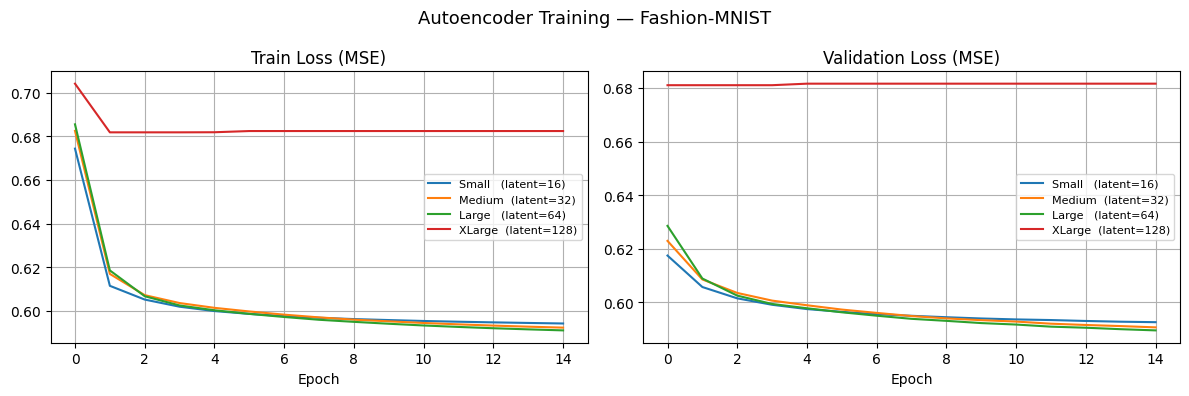

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, res in results.items():
    axes[0].plot(res['train'], label=name)
    axes[1].plot(res['val'],   label=name)

axes[0].set_title('Train Loss (MSE)');      axes[0].set_xlabel('Epoch')
axes[1].set_title('Validation Loss (MSE)'); axes[1].set_xlabel('Epoch')
for ax in axes:
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle('Autoencoder Training — Fashion-MNIST', fontsize=13)
plt.tight_layout()
plt.show()

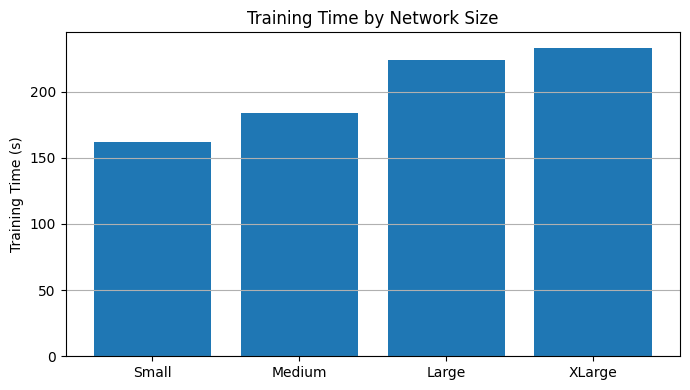

In [32]:
names = list(results.keys())
times = [results[n]['time'] for n in names]

plt.figure(figsize=(7, 4))
plt.bar(range(len(names)), times, tick_label=[n.split('(')[0].strip() for n in names])
plt.ylabel('Training Time (s)')
plt.title('Training Time by Network Size')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

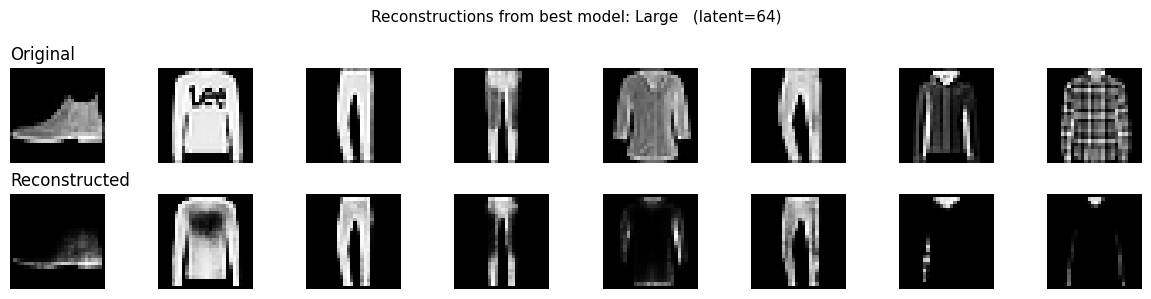

In [33]:
best_name = min(results, key=lambda n: results[n]['val'][-1])
best_model = results[best_name]['model']
best_model.eval()

imgs_batch = next(iter(test_loader))[0][:8].to(DEVICE)
with torch.no_grad():
    recons = best_model(imgs_batch).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(imgs_batch[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recons[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_title('Original', loc='left')
axes[1, 0].set_title('Reconstructed', loc='left')
plt.suptitle(f'Reconstructions from best model: {best_name}', fontsize=11)
plt.tight_layout()
plt.show()

In [34]:
print("  Q3 Autoencoder Diagnostic  ")
print("Algorithm    : Fully connected Autoencoder (MSE loss, Adam optimizer)")
print("Dataset      : Fashion-MNIST (60k train / 10k val / 10k test)")
print(f"Epochs       : {EPOCHS}  |  Batch size: 256  |  LR: 1e-3")
print(f"Device       : {DEVICE}")
print()
for name, res in results.items():
    print(f"  {name:<30}  params={res['params']:>8,}  "
          f"val_loss={res['val'][-1]:.5f}  time={res['time']:.1f}s")
print(f"\nBest validation loss : {best_name}")

  Q3 Autoencoder Diagnostic  
Algorithm    : Fully connected Autoencoder (MSE loss, Adam optimizer)
Dataset      : Fashion-MNIST (60k train / 10k val / 10k test)
Epochs       : 15  |  Batch size: 256  |  LR: 1e-3
Device       : cpu

  Small   (latent=16)             params= 205,856  val_loss=0.59256  time=162.1s
  Medium  (latent=32)             params= 476,720  val_loss=0.59063  time=183.7s
  Large   (latent=64)             params=1,100,112  val_loss=0.58950  time=223.9s
  XLarge  (latent=128)            params=1,165,968  val_loss=0.68160  time=233.1s

Best validation loss : Large   (latent=64)
